In [6]:
!pip install tensorflow kagglehub matplotlib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


In [7]:
path = kagglehub.dataset_download("dansbecker/food-101")
data_dir = os.path.join(path, "images")


Using Colab cache for faster access to the 'food-101' dataset.


In [8]:
IMG_SIZE = (128, 128)   # 🔥 minimum safe size
BATCH_SIZE = 8          # 🔥 lightweight
AUTOTUNE = tf.data.AUTOTUNE


In [10]:
# Correct data_dir to point to the actual image directory within the nested structure.
data_dir = os.path.join(path, "food-101", "food-101", "images")

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.


In [11]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [12]:
train_data = train_data.take(400).cache().prefetch(AUTOTUNE)
val_data = val_data.take(100).cache().prefetch(AUTOTUNE)

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze for speed

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(101, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,   # 🔥 fast but enough learning
    callbacks=[early_stop]
)


Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.0181 - loss: 5.2893 - val_accuracy: 0.0388 - val_loss: 4.8233
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.0625 - loss: 4.6514 - val_accuracy: 0.0812 - val_loss: 4.5452
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1181 - loss: 4.2235 - val_accuracy: 0.1187 - val_loss: 4.3298
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1628 - loss: 3.8959 - val_accuracy: 0.1350 - val_loss: 4.1547
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2341 - loss: 3.5983 - val_accuracy: 0.1663 - val_loss: 4.0106


In [16]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1663 - loss: 4.0106
Validation Accuracy: 0.16625000536441803


In [17]:
calorie_dict = {
    "pizza": 266,
    "burger": 295,
    "ice_cream": 207,
    "salad": 152,
    "sushi": 200
}


In [18]:
from tensorflow.keras.preprocessing import image

def predict_food(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    calories = calorie_dict.get(predicted_class, "Not Available")

    print(f"Predicted Food: {predicted_class}")
    print(f"Estimated Calories: {calories} kcal")

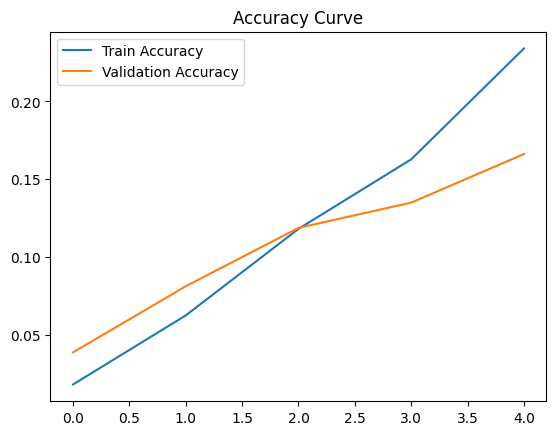

In [25]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

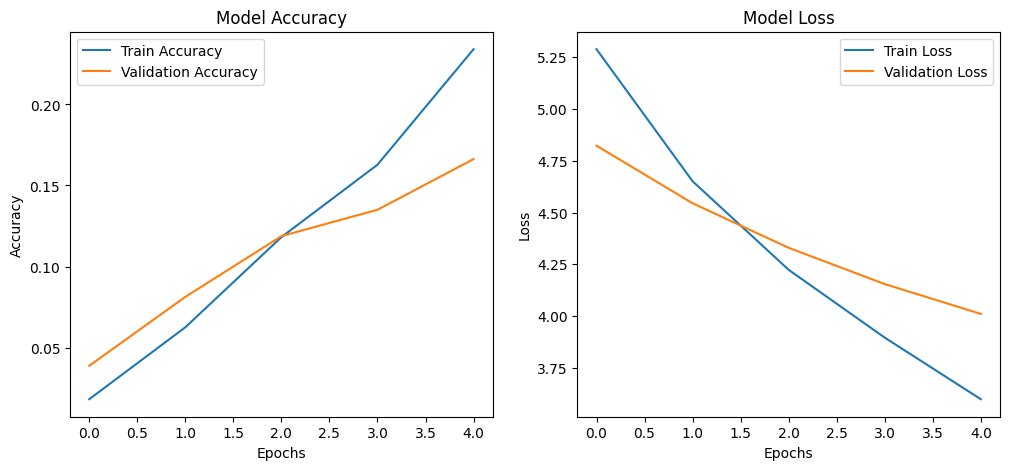

In [26]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()